In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_hub as hub


In [2]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bernardomoraes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df_true = pd.read_csv("True.csv")
df_true = df_true.drop(['subject', 'date'], axis=1)
df_true['label'] = 1
df_true.head()

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [4]:
df_fake = pd.read_csv("Fake.csv")
df_fake = df_fake.drop(['subject', 'date'], axis=1)
df_fake['label'] = 0
df_fake.head()

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0


In [5]:
df = pd.concat([df_true, df_fake], axis=0, ignore_index = True)
df.head()
df.shape

(44898, 3)

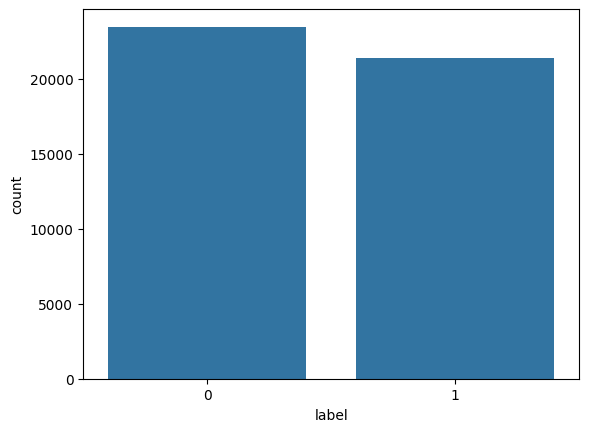

In [6]:
sns.countplot(data=df, x='label')
plt.show()


In [7]:
true_news = df[df['label'] == 1]
fake_news = df[df['label'] == 0]

fake_news_balanced = fake_news.sample(n=len(true_news), random_state=42)

df = pd.concat([true_news, fake_news_balanced]).reset_index(drop=True)
df.shape

(42834, 3)

In [8]:
def remove_stopwords(text):
  stop_words = stopwords.words('english')

  imp_words = []

  for word in text.split():
    word = word.lower()

    if word not in stop_words:
      imp_words.append(word)

  output = " ".join(imp_words)
  return output

df['text'] = df['text'].apply(lambda text: remove_stopwords(text))
df.head()

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",washington (reuters) - head conservative repub...,1
1,U.S. military to accept transgender recruits o...,washington (reuters) - transgender people allo...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,washington (reuters) - special counsel investi...,1
3,FBI Russia probe helped by Australian diplomat...,washington (reuters) - trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,seattle/washington (reuters) - president donal...,1


In [9]:
total_len = len(df['text'])
sum_len = 0
for i in df['text']:
  i = i.split()
  sum_len += len(i)
average_text_len = round(sum_len / total_len)

X_train, X_test, y_train, y_test = train_test_split(
  df['text'],
  df['label'],
  test_size = 0.2,
  random_state = 42
)

X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
  max_tokens = 10000,
  standardize = 'strip_punctuation',
  output_mode = 'int',
  output_sequence_length = average_text_len
)

text_vec.adapt(X_train_np)

In [10]:
def compile_and_fit(model, epochs=5):
  model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
  )

  history = model.fit(
    X_train_np,
    y_train_np,
    epochs = epochs,
    validation_data = (X_test_np, y_test_np)
  )

  return history


def get_metrics(model, X, y):
  y_preds = np.round(model.predict(X))
  return {
    'Accuracy': accuracy_score(y,y_preds),
    'Precision': precision_score(y,y_preds),
    'Recall': recall_score(y,y_preds),
    'F1-Score': f1_score(y,y_preds)
  }

In [12]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=10000, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model1 = keras.Model(input_layer, output_layer, name='Dense_Model')
history_1 = compile_and_fit(model1)

Epoch 1/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9572 - loss: 0.1184 - val_accuracy: 0.9935 - val_loss: 0.0297
Epoch 2/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9962 - loss: 0.0156 - val_accuracy: 0.9931 - val_loss: 0.0260
Epoch 3/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9975 - loss: 0.0100 - val_accuracy: 0.9950 - val_loss: 0.0221
Epoch 4/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9978 - loss: 0.0082 - val_accuracy: 0.9947 - val_loss: 0.0219
Epoch 5/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9996 - loss: 0.0022 - val_accuracy: 0.9946 - val_loss: 0.0249


In [14]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=10000, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model2 = keras.Model(input_layer, output_layer, name='BiLSTM_Model')
history2 = compile_and_fit(model2)

Epoch 1/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 421s 387ms/step - accuracy: 0.9939 - loss: 0.0223 - val_accuracy: 0.9982 - val_loss: 0.0087
Epoch 2/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 415s 387ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9985 - val_loss: 0.0085
Epoch 3/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 405s 379ms/step - accuracy: 0.9995 - loss: 0.0026 - val_accuracy: 0.9981 - val_loss: 0.0102
Epoch 4/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 410s 383ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.9988 - val_loss: 0.0089
Epoch 5/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 406s 379ms/step - accuracy: 0.9998 - loss: 9.4174e-04 - val_accuracy: 0.9980 - val_loss: 0.0134


In [19]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)

input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(x), output_shape=(512,))(input_layer)
x = layers.Dense(64, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model3 = keras.Model(input_layer, output_layer, name='USE_Model')
history3 = compile_and_fit(model3)

Epoch 1/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 58s 51ms/step - accuracy: 0.8775 - loss: 0.3052 - val_accuracy: 0.8982 - val_loss: 0.2411
Epoch 2/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - accuracy: 0.9013 - loss: 0.2359 - val_accuracy: 0.9036 - val_loss: 0.2313
Epoch 3/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.9060 - loss: 0.2259 - val_accuracy: 0.9036 - val_loss: 0.2250
Epoch 4/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.9082 - loss: 0.2181 - val_accuracy: 0.9081 - val_loss: 0.2186
Epoch 5/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 43s 40ms/step - accuracy: 0.9121 - loss: 0.2115 - val_accuracy: 0.9148 - val_loss: 0.2094


In [20]:
results = {
  'Dense Embedding': get_metrics(model1, X_test_np, y_test_np),
  'Bi-LSTM': get_metrics(model2, X_test_np, y_test_np),
  'Transfer Learning': get_metrics(model3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print('Performance Table:')
print(results_df)

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
268/268 ━━━━━━━━━━━━━━━━━━━━ 24s 89ms/step
268/268 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step
Performance Table:
                   Accuracy  Precision    Recall  F1-Score
Dense Embedding    0.994631   0.993256  0.996035  0.994644
Bi-LSTM            0.998016   1.000000  0.996035  0.998014
Transfer Learning  0.914789   0.910855  0.919776  0.915294
